# Credit Risk Modeling: Data Preprocessing & EDA

## Overview
This notebook implements an end-to-end data processing pipeline for credit risk modeling using the Lending Club dataset. The goal is to prepare raw financial data for machine learning by cleaning missing values, removing data leakage, engineering features, and handling outliers.

## Key Steps
1. **Data Loading**: Fetching data directly via Kaggle API.
2. **Data Cleaning**: Handling missing values and removing irrelevant columns.
3. **Feature Engineering**: Creating target variables and transforming categorical features.
4. **Imputation**: Filling missing data using regional statistics.
5. **Outlier Detection**: Using Isolation Forest to identify anomalies.

### 1. Import Libraries
Importing necessary libraries for data manipulation (Pandas, NumPy), visualization (Matplotlib, Seaborn), and machine learning preprocessing.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import kagglehub
import os

warnings.filterwarnings("ignore")

### 2. Load Dataset
We use `kagglehub` to download the **Lending Club Loan Data** directly from Kaggle. This ensures reproducibility and eliminates the need for manual file downloads.

In [4]:
%%time

# Download latest version
path = kagglehub.dataset_download("wordsforthewise/lending-club")

print("Path to dataset files:", path)

path_data_accepted = os.path.join(path, "accepted_2007_to_2018Q4.csv")
path_data_rejected = os.path.join(path, "rejected_2007_to_2018Q4.csv")

df = pd.read_csv(path_data_accepted, low_memory = False)
df.shape

  0%|          | 6.00M/1.26G [00:03<13:34, 1.66MB/s]


KeyboardInterrupt: 

### 3. Data Sampling
The original dataset contains over 2 million records. To speed up the analysis and model training process during development, we sample a subset of the data.
*(Note: Comment out this step when training the final model to use the full dataset.)*

In [ ]:
complete_df = df.sample(n = 1_900_000, random_state = 42)

### 4. Cleaning: Drop Columns with Excessive Missing Data
We calculate the percentage of missing values for each column. Variables with more than **20% missing data** are dropped, as they lack sufficient information for reliable modeling.

In [ ]:
missing_df = complete_df.isna().sum().to_frame().rename(columns = {0: 'count'}).sort_values(by = ['count'], ascending = False)
missing_df['pct'] = round(missing_df['count'] / complete_df.shape[0] * 100, 3)
missing_df['type'] = complete_df.dtypes
missing_df

,count,pct,type
member_id,1900000,100.000,float64
orig_projected_additional_accrued_interest,1892718,99.617,float64
hardship_reason,1890822,99.517,object
hardship_payoff_balance_amount,1890822,99.517,float64
hardship_last_payment_amount,1890822,99.517,float64
...,...,...,...
total_rec_int,29,0.002,float64
disbursement_method,29,0.002,object
hardship_flag,29,0.002,object
debt_settlement_flag,29,0.002,object


### 5. Remove Data Leakage
We drop features that reveal information about the future performance of the loan (e.g., `total_pymnt`, `recoveries`, `last_pymnt_amnt`). These variables are not available at the time of loan application and would cause the model to cheat (data leakage) if included.

In [ ]:
threshold = 20
cols_to_drop = missing_df[missing_df['pct'] > threshold].index
df_cleaned = complete_df.drop(columns = cols_to_drop)
df_cleaned.head()

,id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,...,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,hardship_flag,disbursement_method,debt_settlement_flag
392949,39651438,32000.0,32000.0,32000.0,60 months,10.49,687.65,B,B3,Public Service,...,28.6,0.0,0.0,556496.0,103647.0,64100.0,72197.0,N,Cash,N
1273506,16411620,9600.0,9600.0,9600.0,36 months,12.99,323.42,C,C1,NaN,...,50.0,1.0,0.0,11600.0,4509.0,2400.0,0.0,N,Cash,N
324024,45122316,4000.0,4000.0,4000.0,36 months,6.68,122.93,A,A3,System Analyst,...,0.0,0.0,0.0,222616.0,64253.0,5600.0,76154.0,N,Cash,N
2066630,125356772,6025.0,6025.0,6025.0,36 months,10.91,197.00,B,B4,Admin assistant,...,0.0,0.0,0.0,32227.0,5559.0,11000.0,11127.0,N,Cash,N
477199,128490686,25000.0,25000.0,25000.0,60 months,26.30,752.96,E,E5,Coordinator,...,10.0,0.0,0.0,257219.0,97647.0,179400.0,65719.0,N,Cash,N


In [ ]:
df_cleaned.shape

(1900000, 93)

In [ ]:
df_cleaned.grade.value_counts()

grade
B    558140
C    546642
A    363468
D    272596
E    113959
F     34949
G     10217
Name: count, dtype: int64

In [ ]:
df_cleaned.describe().round(2).T[:30]

,count,mean,std,min,25%,50%,75%,max
loan_amnt,1899971.0,15045.52,9189.82,500.00,8000.00,12900.00,20000.00,40000.00
funded_amnt,1899971.0,15040.23,9187.97,500.00,8000.00,12850.00,20000.00,40000.00
funded_amnt_inv,1899971.0,15021.96,9192.07,0.00,8000.00,12800.00,20000.00,40000.00
int_rate,1899971.0,13.09,4.83,5.31,9.49,12.62,15.99,30.99
installment,1899971.0,445.73,267.17,4.93,251.61,377.71,593.06,1719.83
annual_inc,1899968.0,77943.01,86911.05,0.00,46000.00,65000.00,93000.00,61000000.00
dti,1898541.0,18.82,14.02,-1.00,11.90,17.84,24.49,999.00
delinq_2yrs,1899951.0,0.31,0.87,0.00,0.00,0.00,0.00,58.00
fico_range_low,1899971.0,698.59,33.01,610.00,675.00,690.00,715.00,845.00
fico_range_high,1899971.0,702.59,33.01,614.00,679.00,694.00,719.00,850.00


In [ ]:
df_cleaned.describe().round(2).T[30:]

,count,mean,std,min,25%,50%,75%,max
acc_now_delinq,1899951.0,0.00,0.07,0.0,0.0,0.0,0.0,14.0
tot_coll_amt,1840915.0,235.14,9258.67,0.0,0.0,0.0,0.0,9152545.0
tot_cur_bal,1840915.0,142580.24,160607.61,0.0,29118.0,79383.0,213369.0,9971659.0
total_rev_hi_lim,1840915.0,34589.95,37069.01,0.0,14700.0,25500.0,43200.0,9999999.0
acc_open_past_24mths,1857867.0,4.52,3.16,0.0,2.0,4.0,6.0,64.0
avg_cur_bal,1840855.0,13557.62,16498.25,0.0,3082.0,7343.0,18796.0,958084.0
bc_open_to_buy,1836960.0,11396.91,16601.60,0.0,1723.0,5445.0,14192.0,711140.0
bc_util,1835991.0,57.89,28.58,0.0,35.4,60.2,83.1,339.6
chargeoff_within_12_mths,1899849.0,0.01,0.10,0.0,0.0,0.0,0.0,10.0
delinq_amnt,1899951.0,12.66,740.64,0.0,0.0,0.0,0.0,249925.0


In [ ]:
df_cleaned.nunique()[:40]

id                     1900000
loan_amnt                 1572
funded_amnt               1572
funded_amnt_inv           8742
term                         2
int_rate                   670
installment              89909
grade                        7
sub_grade                   35
emp_title               449286
emp_length                  11
home_ownership               6
annual_inc               80107
verification_status          3
issue_d                    139
loan_status                  9
pymnt_plan                   2
url                    1899971
purpose                     14
title                    54403
zip_code                   951
addr_state                  51
dti                      10334
delinq_2yrs                 37
earliest_cr_line           744
fico_range_low              47
fico_range_high             47
inq_last_6mths              28
open_acc                    89
pub_rec                     38
revol_bal                96692
revol_util                1401
total_ac

In [ ]:
df_cleaned.loan_status.value_counts()

loan_status
Fully Paid                                             904594
Current                                                738655
Charged Off                                            225559
Late (31-120 days)                                      18063
In Grace Period                                          7076
Late (16-30 days)                                        3655
Does not meet the credit policy. Status:Fully Paid       1690
Does not meet the credit policy. Status:Charged Off       644
Default                                                    35
Name: count, dtype: int64

In [ ]:
df_cleaned.loan_status.value_counts().to_frame(name='count').reset_index().rename(columns={'index': 'loan_status'})


,loan_status,count
0,Fully Paid,904594
1,Current,738655
2,Charged Off,225559
3,Late (31-120 days),18063
4,In Grace Period,7076
5,Late (16-30 days),3655
6,Does not meet the credit policy. Status:Fully ...,1690
7,Does not meet the credit policy. Status:Charge...,644
8,Default,35


In [ ]:
df_cleaned.isna().sum()

id                                0
loan_amnt                        29
funded_amnt                      29
funded_amnt_inv                  29
term                             29
                              ...  
total_bc_limit                42133
total_il_high_credit_limit    59085
hardship_flag                    29
disbursement_method              29
debt_settlement_flag             29
Length: 93, dtype: int64

### 6. Target Variable Definition
We define the target variable `loan_condition` to classify loans into two categories:
* **Good Loan**: Status is 'Current' or 'Fully Paid'.
* **Bad Loan**: Status is 'Charged Off', 'Default', 'Late', etc.

### 7. Feature Engineering
* **Employment Length**: Converting the `emp_length` string (e.g., "10+ years") into a numerical format.
* **Dates**: Parsing issue dates and mapping them to relevant time periods.

In [ ]:
bad_loan = ["Charged Off", "Default", "Does not meet the credit policy. Status:Charged Off", "In Grace Period",
            "Late (16-30 days)", "Late (31-120 days)"]
df_cleaned['loan_condition_int'] = df_cleaned['loan_status'].apply(lambda status: 1 if status in bad_loan else 0).astype(int)
df_cleaned['loan_condition'] = np.where(df_cleaned['loan_condition_int'] == 0, 'Good Loan', 'Bad Loan')

#emp_length
emp_length_mapping = {
    '10+ years': 10,
    '9 years': 9,
    '8 years': 8,
    '7 years': 7,
    '6 years': 6,
    '5 years': 5,
    '4 years': 4,
    '3 years': 3,
    '2 years': 2,
    '1 year': 1,
    '< 1 year': 0.5,
    'n/a': 0
}
df_cleaned['emp_length_int'] = df_cleaned['emp_length'].map(emp_length_mapping)
df_cleaned.head().transpose()

# region
state_to_region = {
    'CA': 'West', 'OR': 'West', 'UT': 'West', 'WA': 'West', 'CO': 'West',
    'NV': 'West', 'AK': 'West', 'MT': 'West', 'HI': 'West', 'WY': 'West', 'ID': 'West',
    'AZ': 'SouthWest', 'TX': 'SouthWest', 'NM': 'SouthWest', 'OK': 'SouthWest',
    'GA': 'SouthEast', 'NC': 'SouthEast', 'VA': 'SouthEast', 'FL': 'SouthEast', 'KY': 'SouthEast',
    'SC': 'SouthEast', 'LA': 'SouthEast', 'AL': 'SouthEast', 'WV': 'SouthEast', 'DC': 'SouthEast',
    'AR': 'SouthEast', 'DE': 'SouthEast', 'MS': 'SouthEast', 'TN': 'SouthEast',
    'IL': 'MidWest', 'MO': 'MidWest', 'MN': 'MidWest', 'OH': 'MidWest', 'WI': 'MidWest',
    'KS': 'MidWest', 'MI': 'MidWest', 'SD': 'MidWest', 'IA': 'MidWest', 'NE': 'MidWest',
    'IN': 'MidWest', 'ND': 'MidWest',
    'CT': 'NorthEast', 'NY': 'NorthEast', 'PA': 'NorthEast', 'NJ': 'NorthEast', 'RI': 'NorthEast',
    'MA': 'NorthEast', 'MD': 'NorthEast', 'VT': 'NorthEast', 'NH': 'NorthEast', 'ME': 'NorthEast'
}
df_cleaned['region'] = df_cleaned['addr_state'].map(state_to_region)
df_cleaned.head()

,id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,...,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,hardship_flag,disbursement_method,debt_settlement_flag,loan_condition_int,loan_condition,emp_length_int,region
392949,39651438,32000.0,32000.0,32000.0,60 months,10.49,687.65,B,B3,Public Service,...,103647.0,64100.0,72197.0,N,Cash,N,0,Good Loan,10.0,West
1273506,16411620,9600.0,9600.0,9600.0,36 months,12.99,323.42,C,C1,NaN,...,4509.0,2400.0,0.0,N,Cash,N,0,Good Loan,NaN,SouthEast
324024,45122316,4000.0,4000.0,4000.0,36 months,6.68,122.93,A,A3,System Analyst,...,64253.0,5600.0,76154.0,N,Cash,N,0,Good Loan,4.0,SouthEast
2066630,125356772,6025.0,6025.0,6025.0,36 months,10.91,197.00,B,B4,Admin assistant,...,5559.0,11000.0,11127.0,N,Cash,N,0,Good Loan,10.0,NorthEast
477199,128490686,25000.0,25000.0,25000.0,60 months,26.30,752.96,E,E5,Coordinator,...,97647.0,179400.0,65719.0,N,Cash,N,0,Good Loan,10.0,West


In [ ]:
EDA_df = df_cleaned.copy()

EDA_cat_columns = EDA_df.select_dtypes(include = ['object']).columns.tolist()
EDA_num_columns = EDA_df.select_dtypes(exclude = ['object']).columns.tolist()

# Filter categorical columns with unique value count less than or equal to the specified threshold.
filtered_EDA_cat_columns = [col for col in EDA_cat_columns if EDA_df[col].nunique() <= 50]

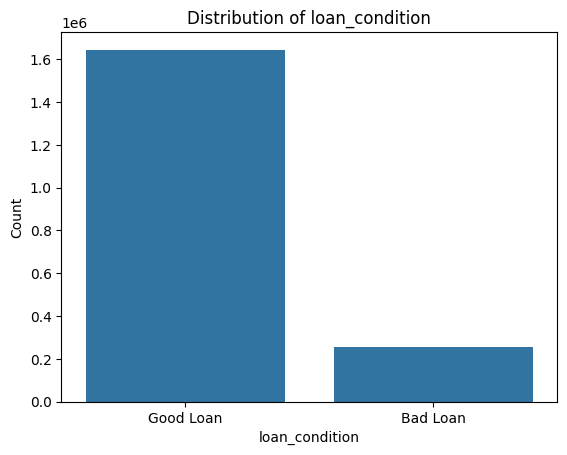

In [ ]:
variable_name = "loan_condition"

sns.countplot(x = variable_name, data = EDA_df)
plt.xlabel(variable_name)
plt.ylabel('Count')
plt.title(f'Distribution of {variable_name}')
plt.show()

### 8. Imputation based on Region
Instead of a simple mean/mode fill, we use a region-based approach for greater accuracy:
* **Categorical Features**: Filled with the **Mode** of the specific region (West, SouthEast, etc.).
* **Numerical Features**: Filled with the **Mean/Median** of the specific region.

In [ ]:
drop_df = df_cleaned
# drop_df = df_cleaned[~df_cleaned['loan_status'].isin(['Current','Issued',])]
drop_df.loan_status.value_counts()

loan_status
Fully Paid                                             904594
Current                                                738655
Charged Off                                            225559
Late (31-120 days)                                      18063
In Grace Period                                          7076
Late (16-30 days)                                        3655
Does not meet the credit policy. Status:Fully Paid       1690
Does not meet the credit policy. Status:Charged Off       644
Default                                                    35
Name: count, dtype: int64

In [ ]:
pd.options.mode.copy_on_write = True


direct_indicators = [
    'collection_recovery_fee',
    'last_pymnt_amnt',
    'out_prncp',
    'out_prncp_inv',
    'recoveries',
    'total_pymnt',
    'total_pymnt_inv',
    'total_rec_int',
    'total_rec_late_fee',
    'total_rec_prncp'
]

drop_df.drop(direct_indicators, axis=1, inplace=True)

In [ ]:
drop_df.shape

(1900000, 87)

In [ ]:
# Assess which are the numerical and categorical features.
numerical_features = df_cleaned.select_dtypes('number').columns.tolist()
categorical_features = df_cleaned.select_dtypes('object').columns.tolist()

print(f'There are {len(numerical_features)} numerical variables in the data. They are: {numerical_features}.')
print(f'There are {len(categorical_features)} categorical variables in the data. They are: {categorical_features}.')

There are 61 numerical variables in the data. They are: ['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'int_rate', 'installment', 'annual_inc', 'dti', 'delinq_2yrs', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'last_fico_range_high', 'last_fico_range_low', 'collections_12_mths_ex_med', 'policy_code', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'total_rev_hi_lim', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'chargeoff_within_12_mths', 'delinq_amnt', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_acc', 'mths_since_recent_bc', 'mths_since_recent_inq', 'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_actv_rev_tl', 'num_bc_sats', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl', 'num_rev_accts', 'num_rev_tl_bal_gt_0', 'num_sats', 'num_tl_120dpd_2m', 'num_tl_30dpd', 'num_tl_90g_dpd_24m', 'num_tl_op_past_12m', 'pct_tl_nvr_dlq', 'percent_bc_gt_75', 'pu

In [ ]:
#drop repeated features

drop_df.drop(['emp_length'], axis=1, inplace=True)

drop_df.drop(['id','emp_title','url','title','zip_code'], axis=1, inplace=True)

# unique values a categorical variable (object) has
drop_df.select_dtypes(include=["object"]).nunique()  #include/exclude

term                      2
grade                     7
sub_grade                35
home_ownership            6
verification_status       3
issue_d                 139
loan_status               9
pymnt_plan                2
purpose                  14
addr_state               51
earliest_cr_line        744
initial_list_status       2
last_pymnt_d            136
last_credit_pull_d      140
application_type          2
hardship_flag             2
disbursement_method       2
debt_settlement_flag      2
loan_condition            2
region                    5
dtype: int64

In [ ]:
fillna_df = drop_df.copy()

# for object variables - Get the mode of next payment date and last payment date and the last date credit amount was pulled
for column in ["last_pymnt_d", "last_credit_pull_d"]:  #, 'income_category'
    fillna_df[column] = fillna_df.groupby("region")[column].transform(lambda x: x.fillna(x.mode()))

# for numerical variables
# Get the mode on the number of accounts in which the client is delinquent
fillna_df["pub_rec"] = fillna_df.groupby("region")["pub_rec"].transform(lambda x: x.fillna(x.median()))
# Get the mode of the total number of credit lines the borrower has
fillna_df["total_acc"] = fillna_df.groupby("region")["total_acc"].transform(lambda x: x.fillna(x.median()))

fillna_df["emp_length_int"] = fillna_df.groupby("region")["emp_length_int"].transform(lambda x: x.fillna(x.median()))

# Get the mean of the annual income depending on the region the client is located.
fillna_df["annual_inc"] = fillna_df.groupby("region")["annual_inc"].transform(lambda x: x.fillna(x.mean()))
# Mode of credit delinquencies in the past two years.
fillna_df["delinq_2yrs"] = fillna_df.groupby("region")["delinq_2yrs"].transform(lambda x: x.fillna(x.mean()))

In [ ]:
# for other, fill in with zero
fillna_df.fillna(0, inplace=True)
fillna_df.isnull().sum().max() # Maximum number of nulls.

np.int64(0)

In [ ]:
len(fillna_df['loan_condition_int'])
# Loan Ratios (Imbalanced classes)
fillna_df['loan_condition_int'].value_counts()/len(fillna_df['loan_condition_int']) * 100

loan_condition_int
0    86.577263
1    13.422737
Name: count, dtype: float64

In [ ]:
fillna_df.isna().sum()

loan_amnt               0
funded_amnt             0
funded_amnt_inv         0
term                    0
int_rate                0
                       ..
debt_settlement_flag    0
loan_condition_int      0
loan_condition          0
emp_length_int          0
region                  0
Length: 81, dtype: int64

### 9. Outlier Detection (Isolation Forest)
We apply the **Isolation Forest** algorithm to detect and remove statistical anomalies in the numerical data. This helps in training a more robust model by reducing the influence of extreme values.

In [ ]:
from sklearn.ensemble import IsolationForest

RemoveOutlier_df = fillna_df.copy()
print("Dataset before removing outlier:",RemoveOutlier_df.shape)

# Áp dụng Isolation Forest
clf = IsolationForest(contamination=0.01, random_state=42)
RemoveOutlier_df['outlier'] = clf.fit_predict(RemoveOutlier_df[numerical_features])

# Loại bỏ ngoại lai
RemoveOutlier_df = RemoveOutlier_df[RemoveOutlier_df['outlier'] == 1]
RemoveOutlier_df.drop(columns='outlier', inplace=True)
RemoveOutlier_df.reset_index(drop=True, inplace=True)
print("Dataset after removing outlier:",RemoveOutlier_df.shape)

RemoveOutlier_df.head().transpose()

Dataset before removing outlier: (1900000, 81)
Dataset after removing outlier: (1881000, 81)


,0,1,2,3,4
loan_amnt,32000.0,9600.0,4000.0,6025.0,25000.0
funded_amnt,32000.0,9600.0,4000.0,6025.0,25000.0
funded_amnt_inv,32000.0,9600.0,4000.0,6025.0,25000.0
term,60 months,36 months,36 months,36 months,60 months
int_rate,10.49,12.99,6.68,10.91,26.3
...,...,...,...,...,...
debt_settlement_flag,N,N,N,N,N
loan_condition_int,0,0,0,0,0
loan_condition,Good Loan,Good Loan,Good Loan,Good Loan,Good Loan
emp_length_int,10.0,6.0,4.0,10.0,10.0


In [ ]:
print(RemoveOutlier_df['issue_d'].head())
dt_series = pd.to_datetime(RemoveOutlier_df['issue_d'], format='%b-%Y', errors='coerce')
RemoveOutlier_df['year'] = dt_series.dt.year


# Điền giá trị NaN bằng cách sử dụng giá trị năm trước đó
RemoveOutlier_df['year'] = RemoveOutlier_df['year'].ffill().astype(int)

0    Feb-2015
1    May-2014
2    Apr-2015
3    Dec-2017
4    Feb-2018
Name: issue_d, dtype: object


[Text(0, 0.5, '(%)')]

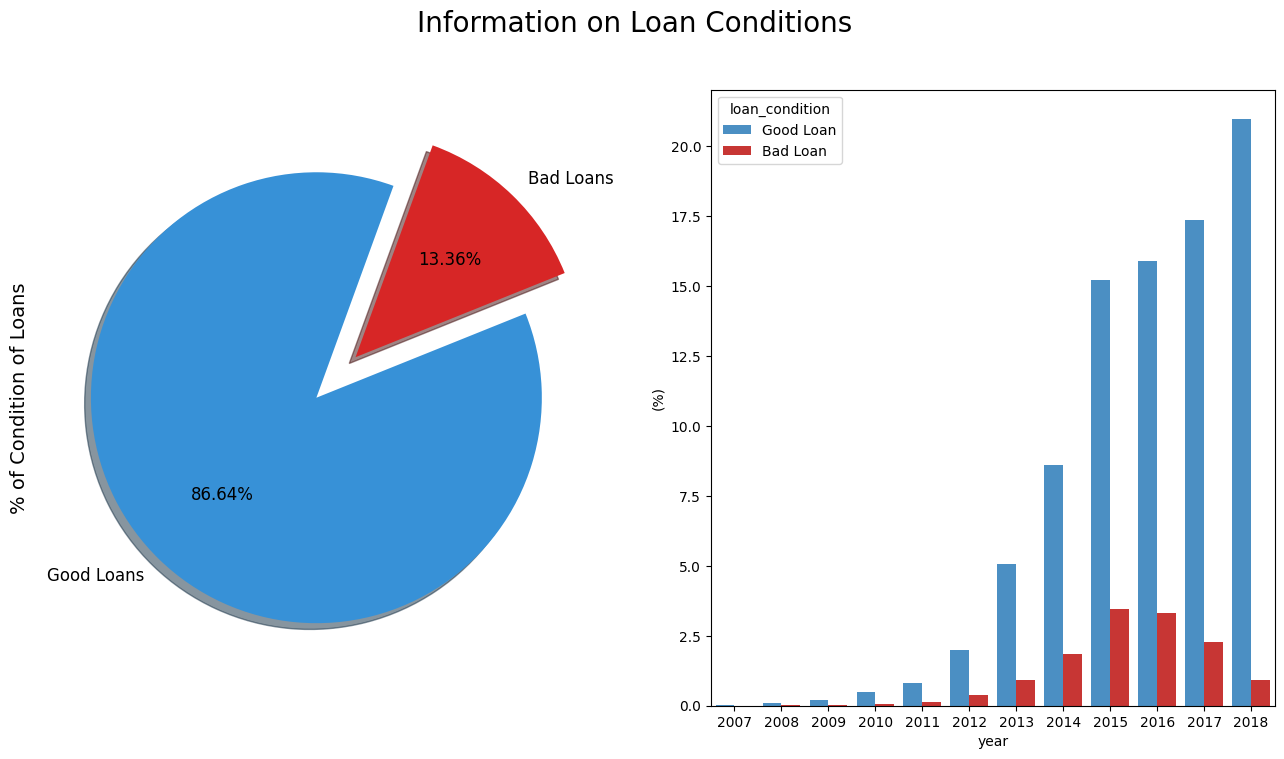

In [ ]:
f, ax = plt.subplots(1,2, figsize=(16,8))

colors = ["#3791D7", "#D72626"]
labels ="Good Loans", "Bad Loans"

plt.suptitle('Information on Loan Conditions', fontsize=20)

RemoveOutlier_df["loan_condition"].value_counts().plot.pie(explode=[0,0.25], autopct='%1.2f%%', ax=ax[0], shadow=True, colors=colors, 
                                             labels=labels, fontsize=12, startangle=70)


# ax[0].set_title('State of Loan', fontsize=16)
ax[0].set_ylabel('% of Condition of Loans', fontsize=14)

# sns.countplot('loan_condition', data=df, ax=ax[1], palette=colors)
# ax[1].set_title('Condition of Loans', fontsize=20)
# ax[1].set_xticklabels(['Good', 'Bad'], rotation='horizontal')
palette = ["#3791D7", "#E01E1B"]

sns.barplot(x="year", y="loan_amnt", hue="loan_condition", data=RemoveOutlier_df, palette=palette, estimator=lambda x: len(x) / len(RemoveOutlier_df) * 100)
ax[1].set(ylabel="(%)")


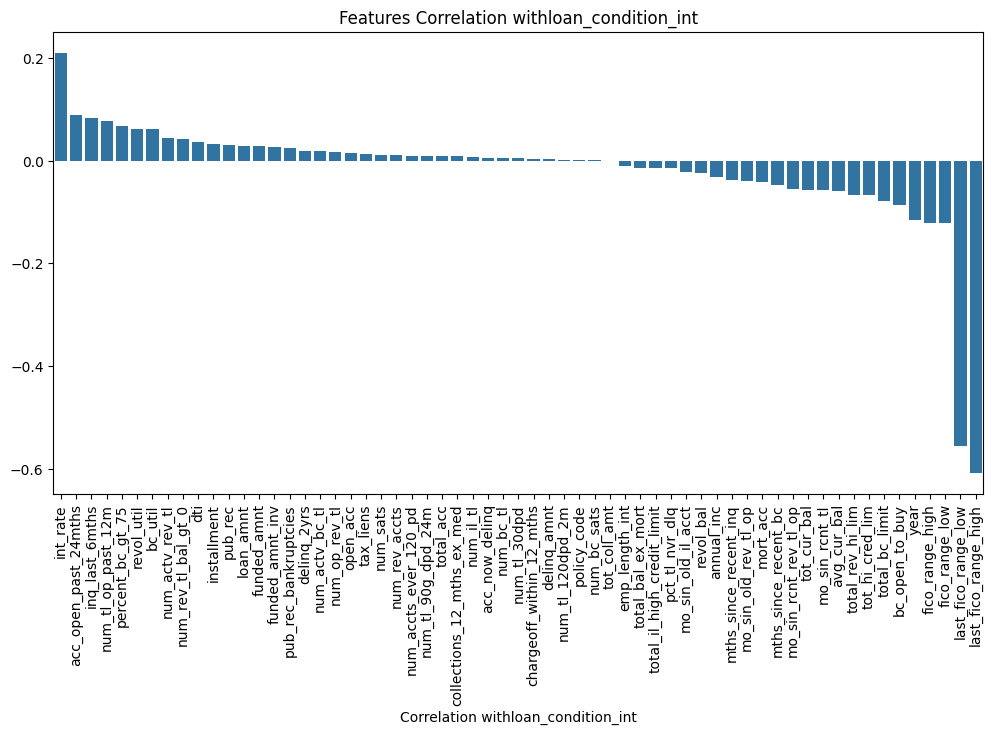

int_rate                0.210206
acc_open_past_24mths    0.089126
inq_last_6mths          0.083452
num_tl_op_past_12m      0.077581
percent_bc_gt_75        0.068364
                          ...   
year                   -0.115907
fico_range_high        -0.121445
fico_range_low         -0.121452
last_fico_range_low    -0.556165
last_fico_range_high   -0.608398
Name: loan_condition_int, Length: 61, dtype: float64


In [ ]:
target_col = target_variable = "loan_condition_int"

corr_df = RemoveOutlier_df.copy() 

# correlation with y
correlation_with_loan_condition = corr_df.select_dtypes(include=['int64', 'float64']).corr()[target_variable]
sorted_correlation = correlation_with_loan_condition.drop(target_variable).sort_values(ascending=False)

# plot
plt.figure(figsize=(12, 6))
sns.barplot(x=sorted_correlation.index, y=sorted_correlation.values, orient='v')
plt.xlabel('Correlation with{}'.format(target_variable))
plt.title('Features Correlation with{}'.format(target_variable))
plt.xticks(rotation=90)
plt.show()
print(sorted_correlation)

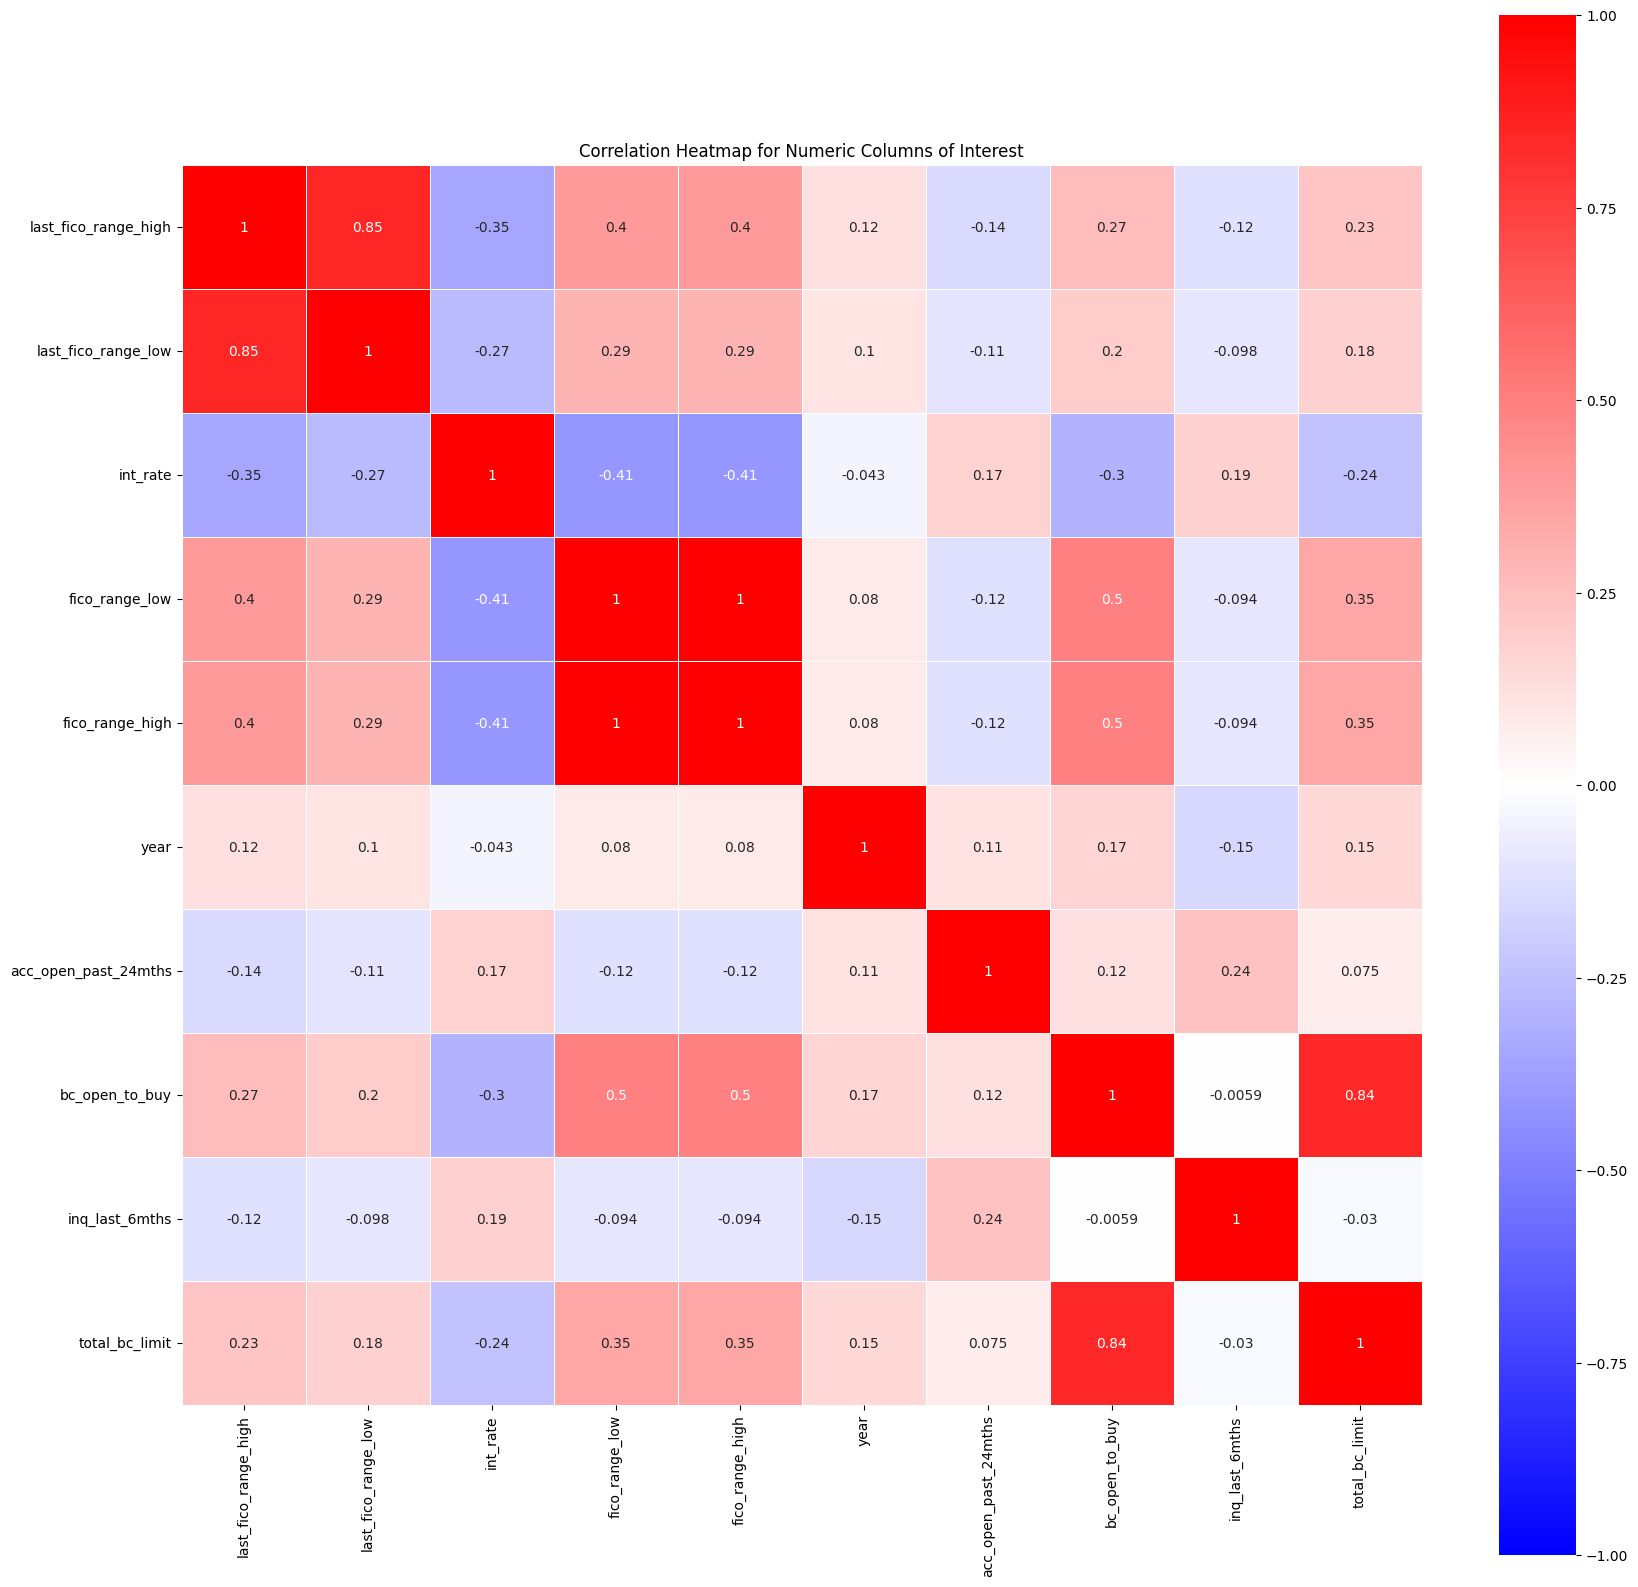

In [ ]:
# Select the variables with the highest correlation with the dependent variable and explore the correlation between them
top_variables = sorted_correlation.abs().nlargest(10).index.tolist()

plt.figure(figsize=(20, 20))
correlation_matrix = RemoveOutlier_df[top_variables].corr()
mask = np.tril(np.ones_like(correlation_matrix, dtype=bool))

sns.heatmap(correlation_matrix, annot=True, cmap='bwr', vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title('Correlation Heatmap for Numeric Columns of Interest')
plt.show()

In [ ]:
df_loan = RemoveOutlier_df

In [ ]:
df_loan = df_loan[df_loan['loan_status'] != 0]

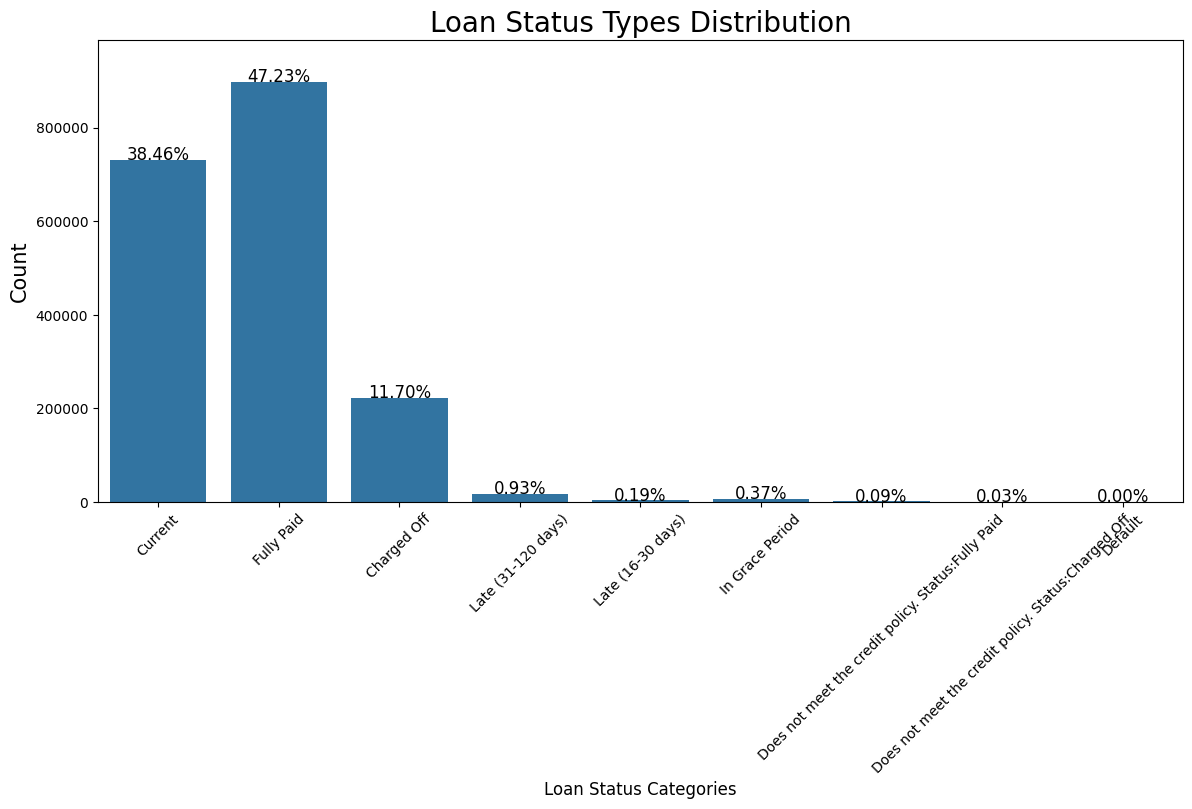

In [ ]:
total = len(df_cleaned)

plt.figure(figsize = (14,6))

g = sns.countplot(x="loan_status", data=df_loan, 
                  )
g.set_xticklabels(g.get_xticklabels(),rotation=45)
g.set_xlabel("Loan Status Categories", fontsize=12)
g.set_ylabel("Count", fontsize=15)
g.set_title("Loan Status Types Distribution", fontsize=20)
sizes=[]
for p in g.patches:
    height = p.get_height()
    sizes.append(height)
    g.text(p.get_x()+p.get_width()/2.,
            height + 3,
            '{:1.2f}%'.format(height/total*100),
            ha="center", fontsize=12) 
g.set_ylim(0, max(sizes) * 1.10)

plt.show()

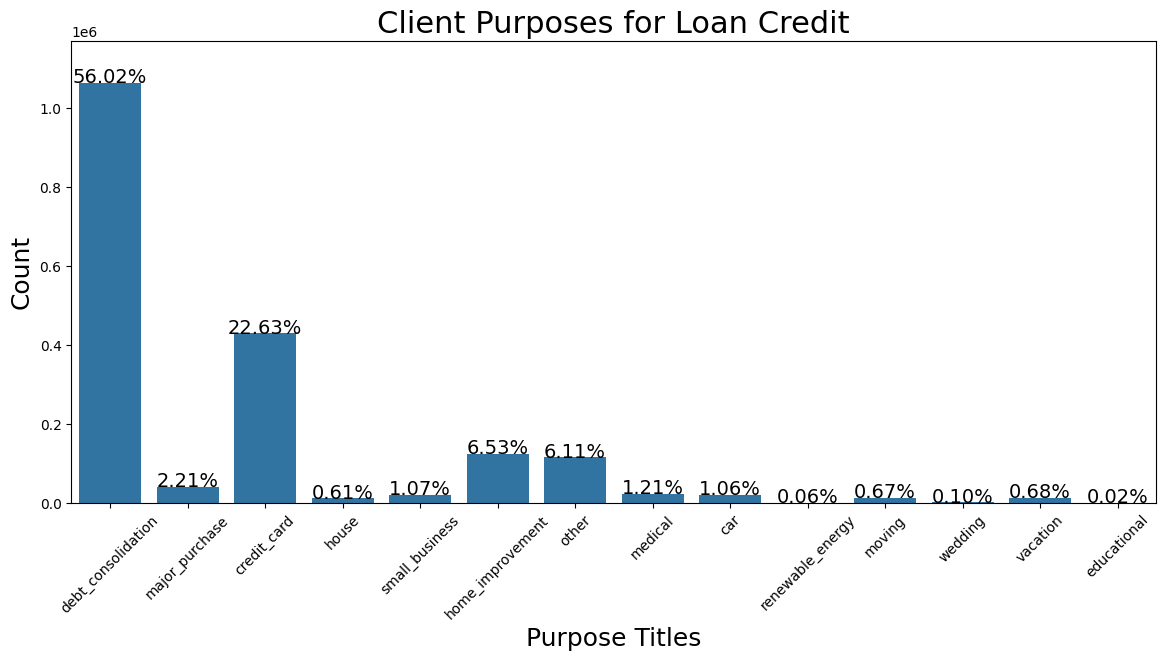

In [ ]:
plt.figure(figsize=(14,6))

g = sns.countplot(x='purpose', data=df_loan, 
                  )
g.set_title("Client Purposes for Loan Credit", fontsize=22)
g.set_xlabel("Purpose Titles", fontsize=18)
g.set_ylabel('Count', fontsize=18)

sizes=[]

for p in g.patches:
    height = p.get_height()
    sizes.append(height)
    g.text(p.get_x()+p.get_width()/2.,
            height + 3,
            '{:1.2f}%'.format(height/total*100),
            ha="center", fontsize=14) 
    
g.set_ylim(0, max(sizes) * 1.10)
g.set_xticklabels(g.get_xticklabels(),
                  rotation=45)

plt.show()

In [ ]:
loan_status_mapping = {
    'Late (31-120 days)': 'Default',
    'In Grace Period': 'Default',
    'Late (16-30 days)': 'Default',
    'Does not meet the credit policy. Status:Charged Off': 'Default'
}

# Sử dụng map() để thay thế các giá trị
df_loan['loan_status'] = df_loan['loan_status'].map(loan_status_mapping).fillna(df_loan['loan_status'])

In [ ]:
#Exploring the loan_status x purpose

purp_loan= ['purpose', 'loan_status']
cm = sns.light_palette("green", as_cmap=True)
(pd.crosstab(df_loan[purp_loan[0]], df_loan[purp_loan[1]], 
                   normalize='columns') * 100).round(2).style.background_gradient(cmap = cm)

AttributeError: The '.style' accessor requires jinja2

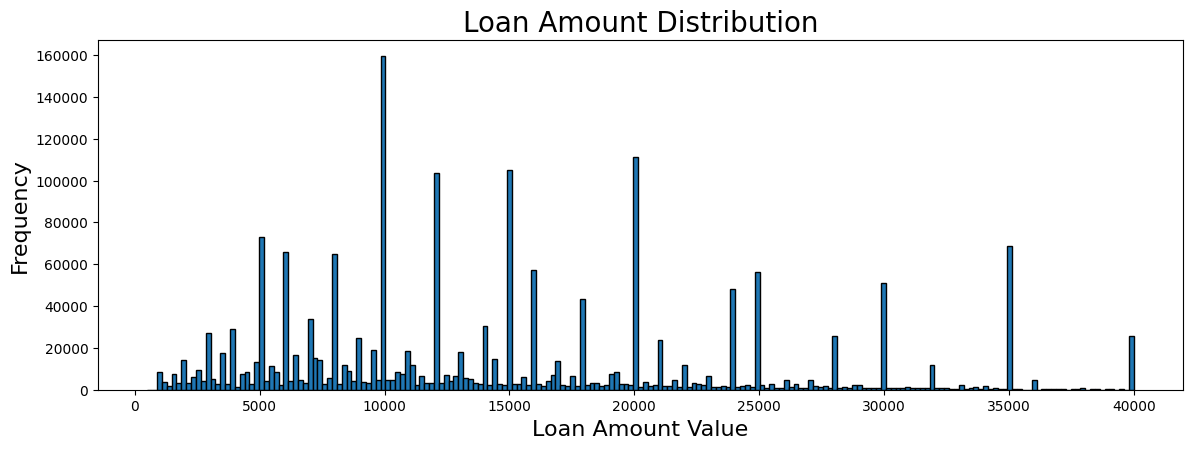

In [ ]:
q75, q25 = np.percentile(df_loan['loan_amnt'].dropna(), [75 ,25])
bin_width = 2 * (q75 - q25) * len(df_loan['loan_amnt']) ** (-1/3)
bins = int((df_loan['loan_amnt'].max() - df_loan['loan_amnt'].min()) / bin_width)

plt.figure(figsize=(14, 10))
plt.subplot(211)
g = plt.hist(df_loan['loan_amnt'], bins=bins, edgecolor='black')
plt.xlabel("Loan Amount Value", fontsize=16)
plt.ylabel("Frequency", fontsize=16)
plt.title("Loan Amount Distribution", fontsize=20)
plt.show()

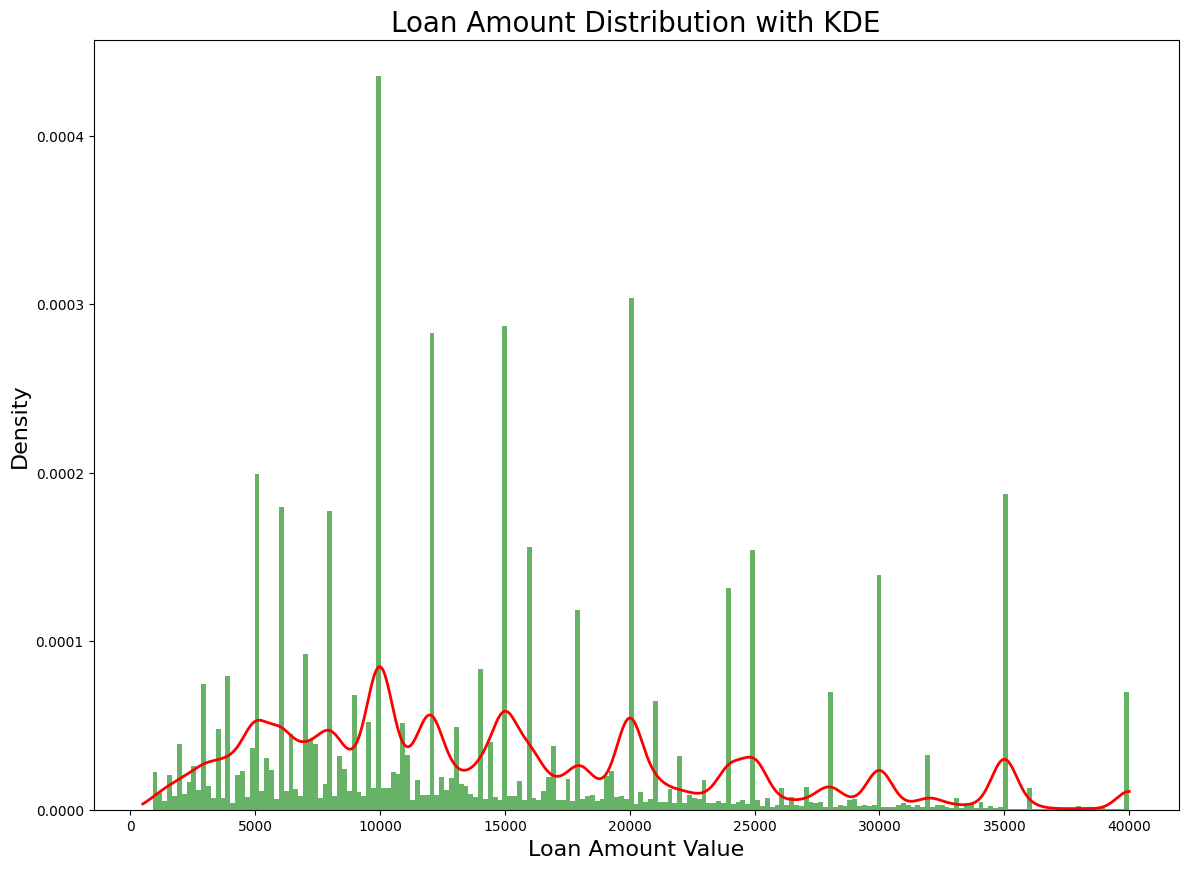

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

data = df_loan['loan_amnt'].dropna()

plt.figure(figsize=(14, 10))

count, bins, ignored = plt.hist(data, bins=bins, density=True, alpha=0.6, color='g')

kde = gaussian_kde(data)
kde_x = np.linspace(min(data), max(data), 1000)
kde_y = kde(kde_x)
plt.plot(kde_x, kde_y, color='red', lw=2)

plt.xlabel("Loan Amount Value", fontsize=16)
plt.ylabel("Density", fontsize=16)
plt.title("Loan Amount Distribution with KDE", fontsize=20)

plt.show()